# Attention Is All You Need — Built From Scratch, Annotated

*A pedagogical, end-to-end re-implementation of the Transformer (Vaswani et al., NeurIPS 2017) in plain PyTorch.*

This notebook rebuilds **every** piece of the paper by hand — scaled dot-product attention, multi-head attention, sinusoidal positional encodings, the encoder/decoder stacks, masking, label smoothing, and the warmup learning-rate schedule — then trains the whole thing on a tiny task so you can watch it actually learn and **look inside the attention heads**.

**How to read this notebook**
- Every code block is preceded by a **theory cell** explaining *why* the code is shaped the way it is, with the exact equations and hyperparameters from the paper.
- We deliberately use **basic PyTorch** (`nn.Linear`, `matmul`, `softmax`) and never `nn.Transformer` — nothing is hidden in a black box.
- Watch for the 🔍 **Nuance** callouts: these are the subtle, easy-to-miss design decisions that separate "I read the paper" from "I understand the paper."

**Paper map → notebook map**
| Paper section | What we build |
|---|---|
| 3.5 Positional Encoding | sinusoidal `PositionalEncoding` |
| 3.2.1 Scaled Dot-Product Attention | `attention()` + the √dₖ variance demo (footnote 4!) |
| 3.2.2 Multi-Head Attention | `MultiHeadAttention` |
| 3.3 Position-wise FFN | `PositionwiseFeedForward` |
| 3.1 Encoder/Decoder Stacks | `EncoderLayer` / `DecoderLayer` + Add&Norm |
| 3.4 Embeddings & Softmax | `Embeddings` (with √d_model scaling & weight tying) |
| 5.3 Optimizer | Noam warmup schedule |
| 5.4 Regularization | dropout + label smoothing |

In [1]:
# ── Foundations: imports, reproducibility, device ──────────────────────────                         # +-- ONE SEED, ONE DEVICE, EVERY NUMBER BELOW REPRODUCIBLE ------
import math, copy, sys                                                                                # | Everything here is built out of plain tensor operations, so
import torch                                                                                          # | the only imports are torch, the functional namespace for relu
import torch.nn as nn                                                                                 # | and log_softmax, and matplotlib for the two diagnostic plots.
import torch.nn.functional as F                                                                       # | The seed is fixed before any module is constructed, because
import matplotlib.pyplot as plt                                                                       # | every weight in this notebook is drawn from the global
                                                                                                      # | generator at construction time; move the seed line and the
# Reproducibility: fix every RNG so your run matches this notebook exactly.                           # | printed numbers change. The device is chosen once and every
torch.manual_seed(0)                                                                                  # | tensor is created on it later, so the same code runs on CPU or
                                                                                                      # | on a T4 without a single branch.
# Device-agnostic. The toy task trains fine on CPU in seconds; if you switch the
# Colab runtime to a T4 GPU it will simply use it.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device :", device)

Python : 3.12.13
PyTorch: 2.11.0+cu128
Device : cuda


## 1. The big picture: what problem is the Transformer solving?

The task is **sequence transduction**: map an input sequence (e.g. an English sentence) to an output sequence (e.g. its German translation). Before this paper, the best models did this with **RNNs/LSTMs**, which process tokens *one at a time* — hidden state `h_t` depends on `h_{t-1}`. That recurrence has two costs the paper attacks head-on:

1. **No parallelism in time.** You can't compute step `t` until step `t-1` is done. Training is serial along the sequence.
2. **Long paths for long-range dependencies.** For a word to influence another `n` positions away, the signal must pass through `O(n)` sequential steps — and gradients decay along the way.

> 🔍 **Nuance (Table 1 of the paper).** Self-attention connects *any* two positions in **O(1)** sequential operations with a maximum path length of **O(1)**, versus **O(n)** for RNNs. This single table is the whole motivation: *shorter paths ⇒ easier to learn long-range dependencies, and constant sequential depth ⇒ full parallelism.* The price is `O(n²·d)` compute per layer — fine when sequence length `n` < dimension `d`.

### The shape of the model
The Transformer keeps the classic **encoder–decoder** skeleton but replaces *all* recurrence/convolution with attention:

```
                 ENCODER (×N=6)                      DECODER (×N=6)
  input tokens                                  output tokens (shifted right)
       │                                                │
   [Embedding × √d_model] + [Positional Encoding]   [Embedding × √d_model] + [PE]
       │                                                │
   ┌───▼─────────────────┐                       ┌──────▼───────────────────┐
   │ Multi-Head SELF-attn │                       │ MASKED Multi-Head SELF-attn│
   │ Add & Norm           │                       │ Add & Norm                 │
   │ Feed-Forward         │                       │ Multi-Head CROSS-attn ◄────┼── encoder output (K,V)
   │ Add & Norm           │                       │ Add & Norm                 │
   └───┬─────────────────┘                       │ Feed-Forward               │
       │ (memory: K,V) ─────────────────────────►│ Add & Norm                 │
       │                                          └──────┬───────────────────┘
                                                         │
                                                  Linear → Softmax → next-token probabilities
```

There are exactly **three** ways attention is used (paper §3.2.3):
- **Encoder self-attention** — each input position attends to all input positions.
- **Decoder masked self-attention** — each output position attends only to *earlier* output positions (preserves the autoregressive property — you can't peek at the future).
- **Encoder–decoder (cross) attention** — decoder positions (queries) attend over the encoder output (keys/values).

We'll build each block bottom-up, then snap them together.

In [2]:
# ── Config: the paper's hyperparameters (base model) vs. our toy model ──────                        # +-- THE PAPER SHRUNK, NOT SIMPLIFIED ---------------------------
# We keep the EXACT structure of the paper, but shrink the numbers so the model                       # | These are the paper's own knobs with smaller numbers: width of
# trains in seconds on CPU. The paper's "base" values are shown for reference.                        # | every vector that flows through the model, how many attention
from dataclasses import dataclass                                                                     # | heads split that width, how wide the feed-forward hidden layer
                                                                                                      # | gets, and how many encoder and decoder layers are stacked.
@dataclass                                                                                            # | Nothing structural is dropped. The per-head dimension is never
class Config:                                                                                         # | stored as a config value because it is forced: each head gets
    d_model: int   = 128    # paper base: 512   — width of every representation                       # | an equal slice of d_model, so the division must come out
    n_heads: int   = 8      # paper base: 8     — number of attention heads (h)                       # | whole. That is what the assert protects. Break it and the
    d_ff: int      = 512    # paper base: 2048  — hidden width of the FFN                             # | reshape inside multi-head attention would silently lose or
    n_layers: int  = 2      # paper base: 6     — stacked encoder/decoder layers (N)                  # | duplicate features instead of raising.
    dropout: float = 0.1    # paper base: 0.1
    # d_k = d_v = d_model / h  (paper §3.2.2). With d_model=128, h=8 -> d_k=16.

cfg = Config()
assert cfg.d_model % cfg.n_heads == 0, "d_model must be divisible by n_heads"
print(cfg)
print("d_k = d_v = d_model / h =", cfg.d_model // cfg.n_heads)

Config(d_model=128, n_heads=8, d_ff=512, n_layers=2, dropout=0.1)
d_k = d_v = d_model / h = 16


## 2. Positional Encoding (§3.5) — giving a bag-of-vectors a sense of order

Here is a subtlety people miss: **attention is permutation-equivariant.** If you shuffle the input tokens, self-attention produces the same set of outputs, just shuffled — it has *no idea* what order the words came in. An RNN gets order for free (it reads left-to-right); the Transformer threw recurrence away, so it must be *told* the positions explicitly.

The paper adds a **positional encoding** vector `PE_pos` (same dimension `d_model`) to each token embedding. They use fixed sinusoids:

$$PE_{(pos,\,2i)} = \sin\!\left(\frac{pos}{10000^{\,2i/d_{model}}}\right), \qquad PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{\,2i/d_{model}}}\right)$$

- `pos` = position in the sequence (0,1,2,…).
- `i` = the dimension index pair. Even dims get a sine, odd dims get a cosine.
- Each dimension is a sinusoid whose **wavelength forms a geometric progression from 2π up to 10000·2π**. Low dimensions oscillate fast (fine-grained position), high dimensions oscillate slowly (coarse position) — exactly like the bits of a binary counter, but continuous.

> 🔍 **Nuance — why this exact form?** The authors *hypothesised it lets the model attend by relative position*, because **for any fixed offset `k`, `PE_{pos+k}` is a linear function of `PE_pos`.** That follows from the trig angle-addition identities: shifting position by `k` is a rotation of each `(sin, cos)` pair by a fixed angle, i.e. a linear (matrix) map independent of `pos`. So a linear projection inside attention can learn "look 3 tokens back" once and apply it everywhere. We'll *prove this numerically* below.

> 🔍 **Nuance — fixed vs. learned.** Table 3 row (E) shows learned positional embeddings give *nearly identical* BLEU. They picked sinusoids anyway because they *may extrapolate to sequence lengths longer than seen in training* (the formula is defined for any `pos`).

In [3]:
# ── PositionalEncoding (§3.5) ───────────────────────────────────────────────                        # +-- POSITION WRITTEN INTO THE VECTOR, NOT LEARNED --------------
class PositionalEncoding(nn.Module):                                                                  # | Attention treats its input as a set: reorder the tokens and
    def __init__(self, d_model, dropout=0.1, max_len=5000):                                           # | the output reorders with them, unchanged. So order has to be
        super().__init__()                                                                            # | added to the vectors themselves. Each pair of feature
        self.dropout = nn.Dropout(p=dropout)  # §5.4: dropout applied to embeddings+PE sum            # | dimensions gets its own frequency, and the position is written
                                                                                                      # | as the sine and cosine of that position times that frequency.
        # Precompute the PE matrix once: shape (max_len, d_model).                                    # | The frequencies fall geometrically from 1 down to 1/10000,
        pe = torch.zeros(max_len, d_model)                                                            # | which is computed as an exponential of a negative multiple of
        position = torch.arange(0, max_len).unsqueeze(1).float()          # (max_len, 1)              # | log 10000 rather than a power, because raising 10000 to a
                                                                                                      # | small fractional power loses precision at the low-frequency
        # div_term = 1 / 10000^(2i/d_model), computed in log-space for stability.                     # | end. The whole table is built once for 5000 positions and
        # 10000^(2i/d_model) = exp( (2i/d_model) * ln(10000) )                                        # | registered as a buffer: it moves to the GPU with the module
        div_term = torch.exp(torch.arange(0, d_model, 2).float()                                      # | and is saved with the weights, but no gradient is ever taken
                             * (-math.log(10000.0) / d_model))            # (d_model/2,)              # | through it.

        pe[:, 0::2] = torch.sin(position * div_term)   # even dims -> sin
        pe[:, 1::2] = torch.cos(position * div_term)   # odd  dims -> cos
        pe = pe.unsqueeze(0)                           # (1, max_len, d_model) for broadcasting over batch

        # register_buffer: part of the module's state (moves with .to(device),
        # saved in state_dict) but NOT a trainable parameter — no gradients.
        self.register_buffer("pe", pe)

    def forward(self, x):                                                                             # +-- ADDED, NOT CONCATENATED ------------------------------------
        # x: (batch, seq_len, d_model). Add the matching slice of precomputed PE.                     # | The encoding is added onto the embeddings, not appended, so
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)                                         # | position costs no extra width. Only the first seq_len rows of
        return self.dropout(x)                                                                        # | the table are used. Dropout is applied to the sum of token and
                                                                                                      # | position, which is what the paper does at the bottom of both
# Smoke test: feed zeros so the output IS purely the positional encoding.                             # | stacks. Feeding zeros in makes the output equal to the
pe_demo = PositionalEncoding(cfg.d_model, dropout=0.0)                                                # | encoding alone, so the shape print is checking the table and
out = pe_demo(torch.zeros(1, 10, cfg.d_model))                                                        # | nothing else.
print("PE output shape:", tuple(out.shape))   # (1, 10, 128)

PE output shape: (1, 10, 128)


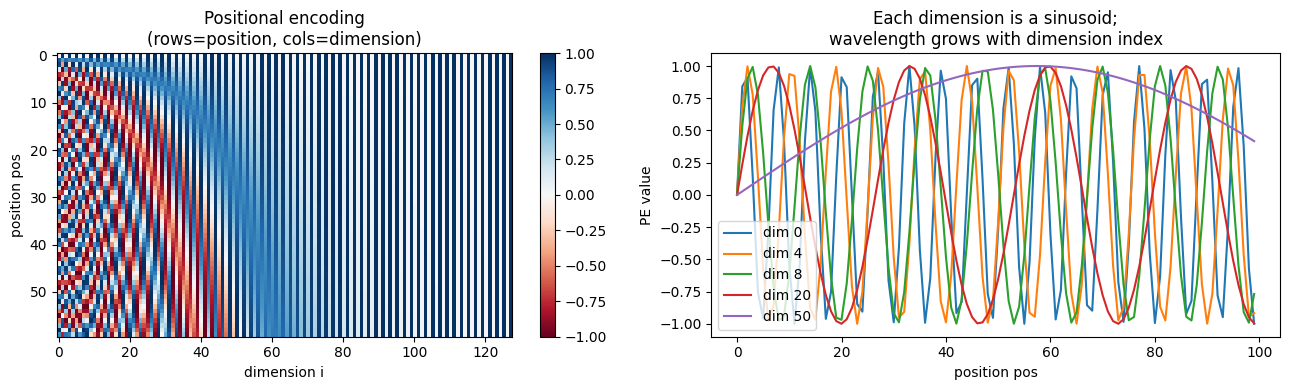

Max error of  PE[pos] @ M  vs  PE[pos+5]  over positions 0..499: 2.10e-05
=> A SINGLE fixed matrix shifts every position by k. Offset = linear map. ✔


In [4]:
# ── Visualizing positional encoding + proving the "linear offset" property ──                        # +-- WHAT THE TABLE ACTUALLY LOOKS LIKE -------------------------
pe_mat = pe_demo.pe[0]  # (max_len, d_model), pure positional encoding                                # | The heatmap has one row per position and one column per
                                                                                                      # | feature dimension. Reading down a column shows a wave; reading
fig, axes = plt.subplots(1, 2, figsize=(13, 4))                                                       # | across a row shows the code for one position. Low dimensions
                                                                                                      # | oscillate every few positions, high dimensions barely turn at
# (Left) The PE matrix as a heatmap: rows = positions, cols = dimensions.                             # | all across the whole window, which is what the geometric
im = axes[0].imshow(pe_mat[:60].numpy(), aspect="auto", cmap="RdBu")                                  # | frequency spread buys: nearby positions differ in the fast
axes[0].set_title("Positional encoding\n(rows=position, cols=dimension)")                             # | dimensions while distant ones are still separated by the slow
axes[0].set_xlabel("dimension i"); axes[0].set_ylabel("position pos")                                 # | ones. The line plot takes five individual dimensions to show
fig.colorbar(im, ax=axes[0])                                                                          # | the same thing as sinusoids whose wavelength grows with the
                                                                                                      # | dimension index.
# (Right) A few individual dimensions as sinusoids of increasing wavelength.
for d in [0, 4, 8, 20, 50]:
    axes[1].plot(pe_mat[:100, d].numpy(), label=f"dim {d}")
axes[1].set_title("Each dimension is a sinusoid;\nwavelength grows with dimension index")
axes[1].set_xlabel("position pos"); axes[1].set_ylabel("PE value"); axes[1].legend()
plt.tight_layout(); plt.show()

# ── Proof that PE[pos+k] is a LINEAR function of PE[pos], independent of pos ──                      # +-- THE OFFSET PROPERTY, CONSTRUCTED NOT FITTED ----------------
# We don't *fit* the map — we CONSTRUCT it from the angle-addition identity:                          # | The claim is that shifting every position by a fixed k is a
#   sin((pos+k)w) = cos(kw)·sin(pos·w) + sin(kw)·cos(pos·w)                                           # | linear map that does not depend on where you start. This is
#   cos((pos+k)w) = -sin(kw)·sin(pos·w) + cos(kw)·cos(pos·w)                                          # | not checked by fitting a matrix to the data, which would prove
# i.e. each (sin,cos) dimension-pair is ROTATED by a fixed angle (k·w_i) that does                    # | nothing; it is built directly from the angle-addition
# not depend on pos. Stacking these 2x2 rotations gives one block-diagonal matrix M                   # | identity. Each sine and cosine pair belongs to one frequency,
# such that  PE[pos] @ M = PE[pos+k]  for EVERY position.                                             # | and advancing the position by k turns that pair through a
k = 5                                                                                                 # | fixed angle k times that frequency. Stacking one two-by-two
d_model = cfg.d_model                                                                                 # | rotation per frequency down the diagonal gives a single
w = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))  # freqs          # | matrix. The four assignments write that rotation in column
M = torch.zeros(d_model, d_model)                                                                     # | order: the new sine column mixes old sine and cosine with cos
for j, wj in enumerate(w):                       # one 2x2 rotation block per freq                    # | and sin of the angle, the new cosine column with minus sin and
    a = (k * wj)                                                                                      # | cos. Multiplying 500 positions by it and comparing against the
    c, s = math.cos(a), math.sin(a)                                                                   # | table shifted by k leaves error at floating-point noise, for
    M[2*j,   2*j] =  c;  M[2*j+1, 2*j]   =  s    # -> new sin column                                  # | every position, with one matrix.
    M[2*j, 2*j+1] = -s;  M[2*j+1, 2*j+1] =  c    # -> new cos column

err = (pe_mat[0:500] @ M - pe_mat[k:500 + k]).abs().max().item()
print(f"Max error of  PE[pos] @ M  vs  PE[pos+{k}]  over positions 0..499: {err:.2e}")
print("=> A SINGLE fixed matrix shifts every position by k. Offset = linear map. ✔")

## 3. Scaled Dot-Product Attention (§3.2.1) — the core operation

Attention maps a **query** and a set of **key–value pairs** to an output. Intuition: the query asks *"what am I looking for?"*, each key advertises *"this is what I contain"*, and the value is *"here's what I'll hand you if you pick me."* The output is a **weighted average of the values**, where the weight of each value is how well its key matches the query.

Packing all queries into a matrix `Q` (n_q × dₖ), all keys into `K` (n_k × dₖ), all values into `V` (n_k × d_v):

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Step by step:
1. **`QKᵀ`** — every query dotted with every key → an `n_q × n_k` matrix of raw similarity *scores*. Dot product is the "compatibility function."
2. **`/ √dₖ`** — the **scaling**. This is the whole reason it's called *scaled* dot-product attention.
3. **`softmax`** (over the key axis) — turn each row of scores into a probability distribution (the *attention weights*; each row sums to 1).
4. **`× V`** — weighted sum of the value vectors.

### Why divide by √dₖ? (the part everyone glosses over)
The paper says: *"for large values of dₖ, the dot products grow large in magnitude, pushing the softmax into regions where it has extremely small gradients."* Footnote 4 gives the math:

> 🔍 **Nuance.** If the components of `q` and `k` are independent with mean 0 and variance 1, then their dot product `q·k = Σ qᵢkᵢ` has **mean 0 and variance dₖ** (variance adds over `dₖ` independent terms). So the *standard deviation* grows like `√dₖ`. Large logits make softmax nearly one-hot → its Jacobian ≈ 0 → **vanishing gradients**, and learning stalls. Dividing by `√dₖ` rescales the variance back to ≈1, keeping softmax in its responsive regime.

We **demonstrate this numerically** in the next cell — it's a beautiful, concrete illustration of why one constant matters.

In [5]:
# ── Footnote 4, made concrete: why the dot products need √d_k scaling ───────                        # +-- WHY THE DOT PRODUCTS ARE DIVIDED BY ROOT D_K ---------------
torch.manual_seed(0)                                                                                  # | Footnote 4 of the paper, measured. If the components of two
print(f"{'d_k':>6} | {'Var(q·k) unscaled':>18} | {'Var after /sqrt(d_k)':>20}")                       # | vectors are independent with mean zero and variance one, their
print("-" * 52)                                                                                       # | dot product is a sum of d_k such products, so its variance is
for d_k in [4, 16, 64, 256, 1024]:                                                                    # | d_k and its spread grows like the square root of d_k. The
    q = torch.randn(20000, d_k)        # rows of unit-variance, mean-0 components                     # | table sweeps d_k over two orders of magnitude and the measured
    k = torch.randn(20000, d_k)                                                                       # | variance tracks it exactly. Dividing by the square root of d_k
    dots = (q * k).sum(-1)             # 20000 independent dot products q·k                           # | pins the variance at one no matter how wide the head is.
    var_unscaled = dots.var().item()
    var_scaled   = (dots / math.sqrt(d_k)).var().item()
    print(f"{d_k:>6} | {var_unscaled:>18.2f} | {var_scaled:>20.3f}")
print("\nVar(q·k) tracks d_k exactly (footnote 4). Dividing by sqrt(d_k) pins it to ~1.")

# Now show the DOWNSTREAM effect: softmax saturation when logits are too large.                       # +-- WHAT LARGE LOGITS DO DOWNSTREAM ----------------------------
scores = torch.randn(64)                              # pretend these are one row of QK^T...          # | The variance matters only because of what softmax does next.
for scale, label in [(8.0, "large logits (no scaling)"), (1.0, "well-scaled logits")]:                # | The same random scores are pushed through softmax at two
    p = torch.softmax(scores * scale, dim=-1)                                                         # | scales and the entropy of the result is measured. Large logits
    # Entropy measures how 'spread out' the attention is (high = soft, 0 = one-hot).                  # | give one probability near one and the rest near zero; the
    entropy = -(p * (p + 1e-12).log()).sum().item()                                                   # | softmax Jacobian is proportional to p times one minus p, so at
    print(f"{label:>28}: max prob = {p.max():.3f}, entropy = {entropy:.3f}")                          # | that point almost no gradient flows back and the weights stop
print("Saturated softmax (max prob ~1, entropy ~0) => almost-zero gradient => stuck learning.")       # | moving.

   d_k |  Var(q·k) unscaled | Var after /sqrt(d_k)
----------------------------------------------------
     4 |               3.98 |                0.994
    16 |              16.07 |                1.004
    64 |              64.25 |                1.004
   256 |             253.06 |                0.989
  1024 |            1015.56 |                0.992

Var(q·k) tracks d_k exactly (footnote 4). Dividing by sqrt(d_k) pins it to ~1.
   large logits (no scaling): max prob = 0.743, entropy = 0.751
          well-scaled logits: max prob = 0.079, entropy = 3.757
Saturated softmax (max prob ~1, entropy ~0) => almost-zero gradient => stuck learning.


In [6]:
# ── Scaled Dot-Product Attention, Eq. (1) ───────────────────────────────────                        # +-- EQUATION 1, IN FOUR LINES ----------------------------------
def attention(query, key, value, mask=None, dropout=None):                                            # | This is the whole of scaled dot-product attention. Every query
    """
    query, key, value: (..., seq_len, d_k)   (the '...' carries batch & head dims)
    mask: broadcastable boolean/0-1 tensor; positions that are 0/False are forbidden.
    Returns: (output, attention_weights).
    """
    d_k = query.size(-1)                                                                              # | is scored against every key by a dot product, the scores are
                                                                                                      # | divided by the root of the head width, softmax turns each
    # 1) raw scores QK^T, then 2) scale by 1/sqrt(d_k).  scores: (..., n_q, n_k)                      # | query's row of scores into weights that sum to one, and the
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)                              # | output is that weighted sum of the value vectors. The leading
                                                                                                      # | dimensions are deliberately left unnamed so the same function
    # Masking: set forbidden positions to -inf so softmax gives them weight 0.                        # | serves a bare three-dimensional batch and the four-dimensional
    # This is how BOTH padding masks and the causal (no-peek) mask are enforced.                      # | batch-by-head case later. Masking is done by writing negative
    if mask is not None:                                                                              # | infinity into the forbidden score positions before the
        scores = scores.masked_fill(mask == 0, float("-inf"))                                         # | softmax, which makes their exponential exactly zero; zeroing
                                                                                                      # | after the softmax instead would leave the remaining weights
    # 3) softmax over the KEY axis -> each query's weights sum to 1.                                  # | not summing to one. Padding and the causal no-peek rule both
    p_attn = scores.softmax(dim=-1)                                                                   # | go through this one line. Dropout is applied to the weights
    if dropout is not None:                                                                           # | themselves, so during training some connections are dropped,
        p_attn = dropout(p_attn)         # attention dropout (used inside training)                   # | not some features.

    # 4) weighted sum of values.  output: (..., n_q, d_v)
    return torch.matmul(p_attn, value), p_attn

# Sanity checks on a tiny example.                                                                    # +-- CHECKING THE TWO INVARIANTS --------------------------------
torch.manual_seed(0)                                                                                  # | Two things must hold for the function to be attention at all.
q = torch.randn(1, 3, 16); k = torch.randn(1, 3, 16); v = torch.randn(1, 3, 16)                       # | The output must carry one vector per query, not per key, and
out, w = attention(q, k, v)                                                                           # | each query's weights must sum to exactly one. The masked call
print("output shape:", tuple(out.shape), "| attn-weights shape:", tuple(w.shape))                     # | then forbids query zero from seeing key two and reads that
print("each query's weights sum to 1:", w.sum(-1).flatten().tolist())                                 # | weight back: it is exactly zero, not merely small, which
                                                                                                      # | confirms the negative infinity reached the softmax rather than
# Demonstrate masking: forbid query 0 from attending to key 2.                                        # | being clipped.
mask = torch.tensor([[[1,1,0],[1,1,1],[1,1,1]]])
_, wm = attention(q, k, v, mask=mask)
print("masked entry (query0->key2) is exactly 0:", wm[0,0,2].item())

output shape: (1, 3, 16) | attn-weights shape: (1, 3, 3)
each query's weights sum to 1: [1.0, 1.0, 1.0]
masked entry (query0->key2) is exactly 0: 0.0


## 4. Multi-Head Attention (§3.2.2) — many attention "views" in parallel

A single attention function forces the model to blend everything into *one* weighted average. The authors found it better to run attention **`h` times in parallel**, each with its own *learned* linear projection of Q, K, V into a smaller `dₖ`-dim subspace, then concatenate the results and project once more:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1,\dots,\text{head}_h)\,W^O$$
$$\text{head}_i = \text{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V)$$

with `Wᵢ^Q, Wᵢ^K ∈ ℝ^{d_model×dₖ}`, `Wᵢ^V ∈ ℝ^{d_model×d_v}`, and `W^O ∈ ℝ^{h·d_v×d_model}`.

- The paper uses **h = 8** heads, with **dₖ = d_v = d_model/h = 512/8 = 64**.

> 🔍 **Nuance — it's (almost) free.** Because each head's dimension shrinks to `d_model/h`, the *total* compute is about the same as one full-dimension attention. You get `h` different "representation subspaces" for the price of one. *"Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. With a single head, averaging inhibits this."*

> 🔍 **Implementation nuance.** Instead of `h` separate small `Linear` layers, the standard trick (which we use) is **one big `Linear(d_model, d_model)` per Q/K/V**, then *reshape* the output to `(batch, h, seq, dₖ)`. Mathematically identical to `h` separate projections, but a single fused matmul — much faster. The four projections `W^Q, W^K, W^V, W^O` are the *only* learnable parameters in attention; attention itself has no weights.

In [7]:
# ── Multi-Head Attention (§3.2.2) ───────────────────────────────────────────                        # +-- FOUR MATRICES, NOT FOUR TIMES h MATRICES -------------------
class MultiHeadAttention(nn.Module):                                                                  # | The paper describes h separate projections per input, each
    def __init__(self, d_model, n_heads, dropout=0.1):                                                # | producing a narrow head. Doing that literally would mean many
        super().__init__()                                                                            # | small matrix multiplies. Instead each of query, key and value
        assert d_model % n_heads == 0                                                                 # | gets one full-width projection, and the split into heads is a
        self.d_k = d_model // n_heads      # per-head dim (=64 in the paper)                          # | reshape of the result: the first d_k features become head
        self.h   = n_heads                                                                            # | zero, the next d_k head one, and so on. The maths is identical
        # Four projections: W^Q, W^K, W^V, W^O. Each is d_model->d_model; the                         # | because the per-head projections are exactly the column blocks
        # split into heads is done by RESHAPING, not by separate matrices.                            # | of the big one, but it runs as a single multiply. The fourth
        self.W_q = nn.Linear(d_model, d_model)                                                        # | matrix mixes the concatenated heads back together. The
        self.W_k = nn.Linear(d_model, d_model)                                                        # | attention weights are kept on the module purely so the plots
        self.W_v = nn.Linear(d_model, d_model)                                                        # | at the end can read out what a trained head looked at.
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.attn = None                   # we stash the last attention weights for viz

    def forward(self, query, key, value, mask=None):                                                  # +-- BATCH AND HEAD BOTH BECOME LEADING AXES --------------------
        if mask is not None:                                                                          # | The mask arrives shaped for a batch of sequences, so a head
            mask = mask.unsqueeze(1)       # add a head axis so the mask broadcasts over heads        # | axis of size one is inserted to let one mask broadcast across
        nbatches = query.size(0)                                                                      # | every head; each head must obey the same padding and causality
                                                                                                      # | rules. The three inputs are projected and then reshaped so
        # 1) Project, then split each into (batch, h, seq, d_k).                                      # | that batch and head lead and the sequence and per-head width
        def shape(x, lin):                                                                            # | follow. This is what lets the attention function above run all
            x = lin(x).view(nbatches, -1, self.h, self.d_k)  # (b, seq, h, d_k)                       # | heads of all sequences as one pair of matrix multiplies.
            return x.transpose(1, 2)                          # (b, h, seq, d_k)                      # | Afterwards the heads are moved back beside each other and
        q = shape(query, self.W_q)                                                                    # | flattened into the full width; the contiguous call is required
        k = shape(key,   self.W_k)                                                                    # | because the transpose left the memory strided and a flattening
        v = shape(value, self.W_v)                                                                    # | view needs it laid out in order. The final projection mixes
                                                                                                      # | across the head boundary, which is the only place where heads
        # 2) Attention in parallel across all heads (the '...' in attention() = b,h).                 # | talk to each other. Passing the same tensor three times is
        x, self.attn = attention(q, k, v, mask=mask, dropout=self.dropout)                            # | self-attention: every position both asks and answers. The
                                                                                                      # | stored weight tensor is indexed by batch, then head, then the
        # 3) Concat heads back together: (b, h, seq, d_k) -> (b, seq, h*d_k=d_model).                 # | position doing the asking, then the position being read, and
        x = x.transpose(1, 2).contiguous().view(nbatches, -1, self.h * self.d_k)                      # | the smoke test prints exactly that. Nothing in this method is
                                                                                                      # | specific to self-attention; the decoder's cross-attention
        # 4) Final output projection W^O.                                                             # | calls it with a different tensor for the query than for the
        return self.W_o(x)                                                                            # | key and value, and the code path is identical.

# Smoke test.
mha = MultiHeadAttention(cfg.d_model, cfg.n_heads, cfg.dropout)
x = torch.randn(2, 7, cfg.d_model)            # (batch=2, seq=7, d_model)
y = mha(x, x, x)                              # self-attention: Q=K=V=x
print("MHA output:", tuple(y.shape), "| stored attn:", tuple(mha.attn.shape))
print("attn dims = (batch, heads, query_pos, key_pos) =", tuple(mha.attn.shape))

MHA output: (2, 7, 128) | stored attn: (2, 8, 7, 7)
attn dims = (batch, heads, query_pos, key_pos) = (2, 8, 7, 7)


## 5. Position-wise Feed-Forward Network (§3.3) & Add-and-Norm (§3.1)

### The FFN
After attention mixes information *across positions*, each layer applies a small MLP **independently and identically to every position**:

$$\text{FFN}(x) = \max(0,\; xW_1 + b_1)\,W_2 + b_2$$

- Inner dimension `d_ff = 2048` (4× wider than `d_model = 512`), with a ReLU in between.
- "Position-wise" = the *same* MLP weights are applied to each position separately (equivalently, two 1×1 convolutions). Attention is the only place tokens talk to each other; the FFN is where each token "thinks" on its own.

> 🔍 **Nuance.** This is where most of the model's *parameters* and a big chunk of the *compute* live (it's 4× wider than the model). A useful mental model: **attention routes information, the FFN processes it.**

### Add & Norm (residual + layer normalization)
Every sub-layer (attention OR ffn) is wrapped as:
$$\text{output} = \text{LayerNorm}\big(x + \text{Sublayer}(x)\big)$$

- The **residual connection** `x + Sublayer(x)` gives gradients a direct highway back through the network (He et al., ResNet) — essential for training a deep stack.
- **LayerNorm** normalizes across the feature dimension per token, stabilizing activations.
- To make residual addition possible, **every sub-layer and embedding outputs the same width `d_model = 512`.**

> 🔍 **Nuance — Post-LN vs Pre-LN.** The original paper puts the norm *after* the residual add (`LayerNorm(x + Sublayer(x))`) — "Post-LN". This is faithful to the paper and what we implement, but it's the reason the original needs the **learning-rate warmup** (next sections): early in training Post-LN gradients are large/unstable. Modern Transformers (GPT-2 onward) often use **Pre-LN** (`x + Sublayer(LayerNorm(x))`), which trains more stably without warmup. We stay faithful to 2017.

In [8]:
# ── Position-wise FFN (§3.3) and the Add&Norm wrapper (§3.1) ─────────────────                       # +-- THE ONLY PLACE WITH NO MIXING ACROSS POSITIONS -------------
class PositionwiseFeedForward(nn.Module):                                                             # | The feed-forward block widens each vector by four, applies a
    def __init__(self, d_model, d_ff, dropout=0.1):                                                   # | ReLU, and projects back. It is applied to every position
        super().__init__()                                                                            # | independently with the same weights, so it moves no
        self.w_1 = nn.Linear(d_model, d_ff)   # expand:  d_model -> d_ff                              # | information between tokens; attention is the only mechanism
        self.w_2 = nn.Linear(d_ff, d_model)   # project: d_ff -> d_model                              # | that does. This is where most of the parameters live, and it
        self.dropout = nn.Dropout(dropout)                                                            # | gives the model somewhere to compute on what attention just
                                                                                                      # | gathered.
    def forward(self, x):
        # max(0, xW1+b1) is ReLU; applied identically to every position.
        return self.w_2(self.dropout(F.relu(self.w_1(x))))
                                                                                                      # +-- POST-LN: NORMALISE AFTER ADDING THE RESIDUAL ---------------
                                                                                                      # | Every sub-layer in both stacks is wrapped in this. Its output
class SublayerConnection(nn.Module):                                                                  # | is dropped out, added to the untouched input, and the sum is
    """Residual connection followed by a layer norm  ->  LayerNorm(x + Sublayer(x)).

    This is faithful POST-LN (paper §3.1). 'sublayer' is a function (a lambda) so
    the SAME wrapper works for attention and for the FFN.
    Dropout (§5.4) is applied to the sublayer output BEFORE adding it back.
    """
    def __init__(self, d_model, dropout=0.1):                                                         # | normalised. Normalising after the addition is the 2017
        super().__init__()                                                                            # | ordering, and it is why the learning rate must warm up: the
        self.norm = nn.LayerNorm(d_model)                                                             # | residual path runs through a norm at every layer. The sub-
        self.dropout = nn.Dropout(dropout)                                                            # | layer arrives as a function so one wrapper serves attention,
                                                                                                      # | which needs three arguments and a mask, and the feed-forward,
    def forward(self, x, sublayer):                                                                   # | which needs one.
        return self.norm(x + self.dropout(sublayer(x)))

# Smoke test.                                                                                         # +-- WHAT LAYERNORM ACTUALLY GUARANTEES -------------------------
ffn = PositionwiseFeedForward(cfg.d_model, cfg.d_ff, cfg.dropout)                                     # | LayerNorm normalises across the feature axis of each token
sub = SublayerConnection(cfg.d_model, cfg.dropout)                                                    # | separately, not across the batch, so a single token's
x = torch.randn(2, 7, cfg.d_model)                                                                    # | statistics never depend on which other sequences are in the
print("FFN out:", tuple(ffn(x).shape))                                                                # | batch. The check prints the per-token mean and standard
print("Add&Norm out:", tuple(sub(x, ffn).shape))                                                      # | deviation across features: near zero and near one, per token,
# After LayerNorm each token vector has ~0 mean and ~1 std across features:                           # | as claimed.
z = sub(x, ffn)
print(f"per-token mean ~ {z.mean(-1).abs().mean():.2e}, per-token std ~ {z.std(-1).mean():.3f}")

FFN out: (2, 7, 128)
Add&Norm out: (2, 7, 128)
per-token mean ~ 6.93e-09, per-token std ~ 1.004


## 6. Masking — two different jobs done by one mechanism

Masks decide which key positions a query is *allowed* to attend to. We set forbidden scores to `−∞` before the softmax (we did this in `attention()`), so they receive weight exactly 0. There are **two kinds**, used in different places:

1. **Padding mask.** We batch sentences of different lengths by padding short ones with a `<pad>` token. Those pad positions carry no meaning, so *every* query must ignore them as keys. Shape broadcasts over query positions.

2. **Causal / subsequent mask (decoder only, §3.2.3).** To preserve the **autoregressive property**, decoder self-attention position `i` may attend only to positions `≤ i` — never the future. *"We need to prevent leftward information flow in the decoder... by masking out (setting to −∞) all values in the input of the softmax which correspond to illegal connections."* Combined with the fact that decoder inputs are **shifted right by one**, this guarantees the prediction at position `i` depends only on outputs `< i`.

> 🔍 **Nuance — why shifting + masking together?** During training we feed the *whole* target sentence at once (for parallelism), but we must stop each position from cheating by looking at the answer. The causal mask is a lower-triangular matrix of 1s. This is the single trick that lets a Transformer train on a whole sequence in parallel yet still behave autoregressively at inference. The decoder mask is the **intersection** of the padding mask AND the causal mask.

In [9]:
# ── Building masks ──────────────────────────────────────────────────────────                        # +-- ONE MECHANISM, TWO DIFFERENT JOBS --------------------------
PAD = 0  # we reserve token id 0 as <pad>                                                             # | Token id zero is reserved for padding, so the padding mask is
                                                                                                      # | just a comparison against it. Its middle axis of size one is
def make_pad_mask(seq, pad=PAD):                                                                      # | what lets one row of keep-or-drop flags apply to every query
    # seq: (batch, seq_len) of token ids. -> (batch, 1, seq_len): 1=keep, 0=pad.                      # | position. The causal mask is the lower triangle including the
    # The middle '1' axis broadcasts over all query positions.                                        # | diagonal: position i may read positions up to and including
    return (seq != pad).unsqueeze(-2)                                                                 # | itself, never past. The decoder needs both at once, and
                                                                                                      # | because both are boolean tensors of broadcast-compatible shape
def subsequent_mask(size):                                                                            # | a single logical AND combines them into one mask that the
    # Lower-triangular (incl. diagonal) of 1s: position i may see positions <= i.                     # | attention function treats identically.
    # Shape (1, size, size).
    return torch.tril(torch.ones(1, size, size)).bool()

def make_decoder_mask(tgt, pad=PAD):
    # Combine padding mask AND causal mask via logical AND.
    return make_pad_mask(tgt, pad) & subsequent_mask(tgt.size(-1)).to(tgt.device)

# Demo: a batch with padding.                                                                         # +-- READING THE MASKS OFF THE SCREEN ---------------------------
seq = torch.tensor([[5, 7, 9, 0, 0]])      # last two are <pad>                                       # | Printing them as integers makes the two jobs visible side by
print("pad mask (1=attendable):\n", make_pad_mask(seq).int())                                         # | side. The padding row has zeros where the pad tokens are, in
                                                                                                      # | every query row at once. The causal matrix is triangular.
print("\ncausal mask for length 5 (row=query i, col=key j; 1 means i may see j):")                    # | Their conjunction has the future blanked out above the
print(subsequent_mask(5).int()[0])                                                                    # | diagonal and the padded columns blanked out everywhere, which
                                                                                                      # | is exactly the set of positions that must never receive
print("\ndecoder mask = padding AND causal:")                                                         # | attention mass.
print(make_decoder_mask(seq).int()[0])
# Notice: future positions are 0 (no peeking) AND the padded columns are 0.

pad mask (1=attendable):
 tensor([[[1, 1, 1, 0, 0]]], dtype=torch.int32)

causal mask for length 5 (row=query i, col=key j; 1 means i may see j):
tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)

decoder mask = padding AND causal:
tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0]], dtype=torch.int32)


## 7. Embeddings & the output projection (§3.4)

Token ids → vectors via a learned lookup table `nn.Embedding(vocab, d_model)`. Two subtle details from the paper:

1. **Scale embeddings by √d_model.** *"In the embedding layers, we multiply those weights by √d_model."* The positional encodings have entries in `[−1, 1]` (vector norm ~√(d_model/2)). With PyTorch's default `N(0,1)` embedding init, a raw token vector already has norm ~√d_model — comparable to the PE. Multiplying by √d_model pushes the token-vector norm up to ~`d_model`, so the **token identity dominates the positional signal** in the sum `embedding + PE`. We measure all three norms in the next cell so you can see the effect rather than take it on faith.

2. **Weight tying.** *"We share the same weight matrix between the two embedding layers and the pre-softmax linear transformation."* The input embedding, the output embedding, and the final `Linear`→vocab that produces logits can all share **one** matrix. This saves a huge number of parameters (vocab × d_model is the biggest table in the model) and ties "the vector for word w going in" to "the direction that votes for word w coming out." *(In our toy build below we keep them separate for clarity, but we'll note exactly where you'd tie them.)*

> 🔍 **Nuance — the Generator.** The final step `Linear(d_model, vocab)` → `log_softmax` is its own little module (often called the *generator*). We output **log-probabilities** (not raw logits) because our loss (KL-divergence with label smoothing, coming up) expects log-probs.

In [10]:
# ── Embeddings (§3.4) and the output Generator ──────────────────────────────                        # +-- TOKEN LOOKUP, SCALED, AND THE WAY BACK OUT -----------------
class Embeddings(nn.Module):                                                                          # | An embedding is a lookup table with one trainable row per
    def __init__(self, d_model, vocab):                                                               # | vocabulary entry. The output is multiplied by the square root
        super().__init__()                                                                            # | of the model width, which is section 3.4 of the paper and is
        self.lut = nn.Embedding(vocab, d_model)                                                       # | measured on the next lines. The generator does the reverse at
        self.d_model = d_model                                                                        # | the top of the decoder: one linear map from model width to
                                                                                                      # | vocabulary size, then a log-softmax. Log-probabilities rather
    def forward(self, x):                                                                             # | than probabilities because the loss below is a KL divergence,
        # x: (batch, seq) of token ids -> (batch, seq, d_model), scaled by sqrt(d_model).             # | which expects its input already in log space, and because a
        return self.lut(x) * math.sqrt(self.d_model)                                                  # | log-softmax subtracts the maximum logit internally instead of
                                                                                                      # | exponentiating a large number and dividing. Note that these
                                                                                                      # | two modules are not tied here: the embedding table and the
class Generator(nn.Module):                                                                           # | output projection hold separate weights, whereas the paper
    """Final linear projection to vocab logits, then log-softmax -> log-probabilities."""             # | shares one matrix between them and saves a vocabulary-sized
    def __init__(self, d_model, vocab):                                                               # | tensor.
        super().__init__()
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        return F.log_softmax(self.proj(x), dim=-1)

# Smoke test + an HONEST look at what the sqrt(d_model) scaling actually does.                        # +-- WHAT THE ROOT-D_MODEL SCALING BUYS -------------------------
emb = Embeddings(cfg.d_model, vocab=11)                                                               # | The embedding table is initialised from a unit normal, so a
gen = Generator(cfg.d_model, vocab=11)                                                                # | freshly drawn token vector has length near the square root of
ids = torch.tensor([[1, 2, 3, 4]])                                                                    # | the width. The positional encoding is built from sines and
                                                                                                      # | cosines, so its entries sit in minus one to one and its length
unscaled = emb.lut(ids)                  # raw lookup, no scaling                                     # | is fixed regardless of training. Without the scaling the two
scaled   = emb(ids)                      # = unscaled * sqrt(d_model)                                 # | would be added at comparable magnitudes and the position would
pe_norm  = pe_demo.pe[0, :4].norm(dim=-1).mean()                                                      # | drown the identity of the token. Multiplying by the square
                                                                                                      # | root of the width lifts the token vector an order of magnitude
print(f"sqrt(d_model) = {math.sqrt(cfg.d_model):.2f}")                                                # | above the positional one; the three printed norms are the
print(f"raw embedding vector norm      ~ {unscaled.norm(dim=-1).mean():.1f}  "                        # | measurement. The last line confirms the generator's output
      f"(nn.Embedding inits ~N(0,1), so norm ~ sqrt(d_model))")                                       # | really is a distribution once exponentiated.
print(f"scaled embedding vector norm   ~ {scaled.norm(dim=-1).mean():.1f}  "
      f"(multiplied by sqrt(d_model) -> ~ d_model)")
print(f"positional-encoding vec norm   ~ {pe_norm:.1f}  (entries in [-1,1])")
print("=> scaling lifts the TOKEN signal well above the POSITION signal before they're summed.")
logp = gen(scaled)
print("\ngenerator out (log-probs):", tuple(logp.shape),
      "| each row sums to 1 in prob space:", f"{logp.exp().sum(-1).mean():.3f}")

sqrt(d_model) = 11.31
raw embedding vector norm      ~ 11.1  (nn.Embedding inits ~N(0,1), so norm ~ sqrt(d_model))
scaled embedding vector norm   ~ 125.1  (multiplied by sqrt(d_model) -> ~ d_model)
positional-encoding vec norm   ~ 8.0  (entries in [-1,1])
=> scaling lifts the TOKEN signal well above the POSITION signal before they're summed.

generator out (log-probs): (1, 4, 11) | each row sums to 1 in prob space: 1.000


## 8. The Encoder: one layer, stacked N times (§3.1)

Each **encoder layer** has exactly two sub-layers, each wrapped in Add&Norm:
1. Multi-head **self**-attention (Q, K, V all come from the previous layer's output).
2. Position-wise feed-forward.

The encoder is `N = 6` of these stacked. A final LayerNorm is applied at the very top (a common, faithful implementation detail to keep the output well-scaled).

> 🔍 **Nuance — what "self" means.** In the encoder, attention is *self*-attention: every position looks at every other position **in the same sequence**, with no mask except padding. This is the layer that lets "making" find "more difficult" across the whole sentence in one hop (the paper's Figure 3 visualization). We use `copy.deepcopy` to make `N` genuinely independent layers — each has *its own* weights ("they use different parameters from layer to layer").

In [11]:
# ── Encoder layer and the N-layer stack (§3.1) ──────────────────────────────                        # +-- DEEP COPIES: STACKED, NOT SHARED ---------------------------
def clones(module, n):                                                                                # | Every layer in a stack must own its parameters. A deep copy is
    "Produce n independent deep copies of a module (each gets its own parameters)."                   # | taken per layer, so passing one prototype module in does not
    return nn.ModuleList([copy.deepcopy(module) for _ in range(n)])                                   # | silently tie the six layers together. An encoder layer is two
                                                                                                      # | sub-layers: self-attention, where query, key and value are all
class EncoderLayer(nn.Module):                                                                        # | the same tensor so every position may read every other, and
    def __init__(self, d_model, self_attn, feed_forward, dropout):                                    # | then the position-wise feed-forward. Each is handed to its own
        super().__init__()                                                                            # | residual-and-norm wrapper. The lambda exists so the attention
        self.self_attn = self_attn                                                                    # | call, with its three arguments and mask, is not made until the
        self.feed_forward = feed_forward                                                              # | wrapper has taken the residual copy, which is what keeps the
        self.sublayer = clones(SublayerConnection(d_model, dropout), 2)  # one per sub-layer          # | wrapper ignorant of what it wraps. The encoder mask is the
                                                                                                      # | padding mask only: an encoder position is allowed to read the
    def forward(self, x, mask):                                                                       # | whole sentence in both directions.
        # Sub-layer 1: self-attention (note Q=K=V=x). lambda defers the call so
        # SublayerConnection can wrap it with residual + norm.
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        # Sub-layer 2: position-wise FFN.
        return self.sublayer[1](x, self.feed_forward)

class Encoder(nn.Module):                                                                             # +-- THE STACK, PLUS ONE NORM ON TOP ----------------------------
    def __init__(self, layer, n, d_model):                                                            # | Layers are applied in order, each seeing the previous output
        super().__init__()                                                                            # | and the same source mask, since padding does not change with
        self.layers = clones(layer, n)                                                                # | depth. One extra LayerNorm sits above the stack. The width
        self.norm = nn.LayerNorm(d_model)     # final norm on top of the stack                        # | never changes anywhere in the model: input and output of the
                                                                                                      # | encoder have identical shape, which is what allows the layers
    def forward(self, x, mask):                                                                       # | to be stacked at all and what makes the residual additions
        for layer in self.layers:                                                                     # | legal without any projection. The smoke test builds a two-
            x = layer(x, mask)                                                                        # | layer encoder with an all-ones mask, meaning nothing is
        return self.norm(x)                                                                           # | padded, and confirms shape is preserved. Its input is random
                                                                                                      # | noise rather than embeddings, which is enough: the encoder
# Smoke test.                                                                                         # | never looks at token ids, only at vectors of the right width,
enc_layer = EncoderLayer(cfg.d_model,                                                                 # | so shapes and masks are the only things that can be wrong
                         MultiHeadAttention(cfg.d_model, cfg.n_heads, cfg.dropout),                   # | here.
                         PositionwiseFeedForward(cfg.d_model, cfg.d_ff, cfg.dropout),
                         cfg.dropout)
encoder = Encoder(enc_layer, cfg.n_layers, cfg.d_model)
x = torch.randn(2, 7, cfg.d_model)
src_mask = torch.ones(2, 1, 7).bool()
print("encoder out:", tuple(encoder(x, src_mask).shape))

encoder out: (2, 7, 128)


## 9. The Decoder: three sub-layers per layer (§3.1)

Each **decoder layer** adds a third sub-layer compared to the encoder:
1. **Masked** multi-head self-attention (uses the causal+padding mask, so it can't look ahead).
2. **Encoder–decoder (cross) attention**: the queries come from the decoder, but the **keys and values come from the encoder output** (`memory`). This is how the decoder reads the source sentence.
3. Position-wise feed-forward.

Each wrapped in Add&Norm; `N = 6` layers stacked, plus a final LayerNorm.

> 🔍 **Nuance — two masks, two roles.** The decoder juggles *two* masks. `tgt_mask` (causal + target padding) constrains sub-layer 1. `src_mask` (source padding only — no causal mask, the decoder is allowed to see the *entire* source) constrains the cross-attention in sub-layer 2. Getting these two masks right is the single most common bug when people implement a Transformer from scratch.

> 🔍 **Nuance — where translation actually happens.** Sub-layer 2 (cross-attention) is the bridge between the two towers. Its attention weights are exactly the "soft alignment" between target words and source words — the thing classic attention-based NMT (Bahdanau 2014) introduced, now generalized to multi-head.

In [12]:
# ── Decoder layer and stack (§3.1) ──────────────────────────────────────────                        # +-- THREE SUB-LAYERS, AND WHERE THE ENCODER ENTERS -------------
class DecoderLayer(nn.Module):                                                                        # | The decoder layer differs from the encoder layer by one sub-
    def __init__(self, d_model, self_attn, src_attn, feed_forward, dropout):                          # | layer. First, self-attention over the tokens generated so far,
        super().__init__()                                                                            # | carrying the causal mask so no position can read its own
        self.self_attn = self_attn        # masked self-attention                                     # | future. Second, cross-attention: the queries come from the
        self.src_attn  = src_attn         # encoder-decoder (cross) attention                         # | decoder, but the keys and values come from the encoder output,
        self.feed_forward = feed_forward                                                              # | which is where the source sequence enters the decoder at all.
        self.sublayer = clones(SublayerConnection(d_model, dropout), 3)  # three sub-layers           # | It is masked with the source mask, not the target mask,
                                                                                                      # | because what is being read is the source and only its padding
    def forward(self, x, memory, src_mask, tgt_mask):                                                 # | is forbidden. Third, the same feed-forward.
        m = memory                                                     # encoder output (K,V source)
        # 1) masked self-attention over the decoder's own tokens.
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        # 2) cross-attention: query=decoder x, key/value=encoder memory.
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        # 3) feed-forward.
        return self.sublayer[2](x, self.feed_forward)

class Decoder(nn.Module):                                                                             # +-- THE SAME MEMORY FOR EVERY LAYER AND EVERY STEP -------------
    def __init__(self, layer, n, d_model):                                                            # | The encoder output is passed unchanged into every decoder
        super().__init__()                                                                            # | layer; it is computed once for a sequence and never depends on
        self.layers = clones(layer, n)                                                                # | what the decoder has produced. That is the property the greedy
        self.norm = nn.LayerNorm(d_model)                                                             # | decoder below relies on to run the encoder a single time. The
                                                                                                      # | stack is otherwise identical in shape to the encoder, ending
    def forward(self, x, memory, src_mask, tgt_mask):                                                 # | in its own final norm. The smoke test uses a target of length
        for layer in self.layers:                                                                     # | six against a source of length seven to make the point that
            x = layer(x, memory, src_mask, tgt_mask)                                                  # | the two sides need not match: the output has one vector per
        return self.norm(x)                                                                           # | target position, and the source length only shows up inside
                                                                                                      # | the cross-attention weights, which are rectangular rather than
# Smoke test.                                                                                         # | square. This is the whole reason the architecture can
dec_layer = DecoderLayer(cfg.d_model,                                                                 # | translate between languages whose sentences differ in length.
                         MultiHeadAttention(cfg.d_model, cfg.n_heads, cfg.dropout),
                         MultiHeadAttention(cfg.d_model, cfg.n_heads, cfg.dropout),
                         PositionwiseFeedForward(cfg.d_model, cfg.d_ff, cfg.dropout),
                         cfg.dropout)
decoder = Decoder(dec_layer, cfg.n_layers, cfg.d_model)
memory = encoder(x, src_mask)                       # pretend encoder output
tgt = torch.randn(2, 6, cfg.d_model)
tgt_mask = subsequent_mask(6)
print("decoder out:", tuple(decoder(tgt, memory, src_mask, tgt_mask).shape))

decoder out: (2, 6, 128)


## 10. Assembling the full Transformer

Now we snap the towers together into one `EncoderDecoder`:
- `encode(src)` → run embeddings+PE through the encoder → **memory**.
- `decode(memory, tgt)` → run target embeddings+PE through the decoder, attending to memory.
- `Generator` turns the decoder output into next-token log-probabilities.

`make_model` wires everything and — importantly — **initializes parameters with Xavier/Glorot uniform**, which the original implementation uses to keep activation variances sane at the start of training.

> 🔍 **Nuance — parameter accounting.** Count where the parameters live and you'll understand the model's "shape": the big chunks are the embedding tables (`vocab × d_model`) and the FFNs (`2 × d_model × d_ff` per layer, the 4× expansion). Attention is comparatively cheap in parameters (`4 × d_model²` per layer). Run the cell to see the breakdown.

In [13]:
# ── Full encoder-decoder model + factory ────────────────────────────────────                        # +-- THE TWO HALVES, AND WHY FORWARD RETURNS STATES -------------
class EncoderDecoder(nn.Module):                                                                      # | The model holds five parts: the two stacks, the two input
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):                            # | pipelines that turn ids into embedded and positioned vectors,
        super().__init__()                                                                            # | and the generator. Encoding and decoding are separate methods
        self.encoder = encoder                                                                        # | because inference needs to call them at different rates, once
        self.decoder = decoder                                                                        # | and many times respectively. Forward runs the pair for
        self.src_embed = src_embed     # Embeddings + PositionalEncoding (source)                     # | teacher-forced training, and deliberately stops at the decoder
        self.tgt_embed = tgt_embed     # Embeddings + PositionalEncoding (target)                     # | states rather than applying the generator, so the caller can
        self.generator = generator                                                                    # | decide whether to project the whole sequence, as training
                                                                                                      # | does, or just the last position, as decoding does. Projecting
    def encode(self, src, src_mask):                                                                  # | every position during generation would multiply by the full
        return self.encoder(self.src_embed(src), src_mask)                                            # | vocabulary matrix for tokens whose answers are already fixed.

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

    def forward(self, src, tgt, src_mask, tgt_mask):
        memory = self.encode(src, src_mask)
        return self.decode(memory, src_mask, tgt, tgt_mask)   # (returns decoder states; apply generator for logits)


def make_model(src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1):                  # +-- WIRING, WITH DEEP COPIES AT EVERY BRANCH -------------------
    "Wire up a full Transformer exactly per the paper's structure."                                   # | The prototypes are built once and copied into each slot, so
    attn = MultiHeadAttention(d_model, h, dropout)                                                    # | encoder self-attention, decoder self-attention and cross-
    ff   = PositionwiseFeedForward(d_model, d_ff, dropout)                                            # | attention are three independent sets of weights that merely
    pos  = PositionalEncoding(d_model, dropout)                                                       # | started from the same construction. The same holds for the two
    model = EncoderDecoder(                                                                           # | embedding pipelines and the positional encoding. The defaults
        Encoder(EncoderLayer(d_model, copy.deepcopy(attn), copy.deepcopy(ff), dropout), N, d_model),  # | on this function are the paper's base model, and the toy sizes
        Decoder(DecoderLayer(d_model, copy.deepcopy(attn), copy.deepcopy(attn),                       # | are passed in at the call below. Every parameter with more
                             copy.deepcopy(ff), dropout), N, d_model),                                # | than one dimension is re-initialised with Xavier uniform,
        nn.Sequential(Embeddings(d_model, src_vocab), copy.deepcopy(pos)),                            # | which scales the initial spread by the fan-in and fan-out so
        nn.Sequential(Embeddings(d_model, tgt_vocab), copy.deepcopy(pos)),                            # | that activations neither grow nor shrink through the depth;
        Generator(d_model, tgt_vocab),                                                                # | biases and norm gains, being one-dimensional, keep their
    )                                                                                                 # | defaults.
    # Xavier-uniform init for every multi-dim parameter (paper's tensor2tensor default).
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model

# Build the toy model we'll actually train (vocab of 11: ids 0..10, 0 = <pad>).                       # +-- A VOCABULARY OF ELEVEN AND WHERE THE WEIGHTS SIT -----------
V = 11                                                                                                # | The toy vocabulary is eleven ids: zero is padding, one is the
model = make_model(V, V, N=cfg.n_layers, d_model=cfg.d_model,                                         # | start symbol, and two through ten are the symbols to copy. The
                   d_ff=cfg.d_ff, h=cfg.n_heads, dropout=cfg.dropout).to(device)                      # | per-part parameter counts are worth reading. The feed-forward
                                                                                                      # | blocks inside the stacks dominate, the attention projections
total = sum(p.numel() for p in model.parameters())                                                    # | are four square matrices per attention, and the embeddings are
print(f"Total trainable parameters: {total:,}")                                                       # | tiny only because this vocabulary is tiny; at real vocabulary
for name, mod in [("encoder", model.encoder), ("decoder", model.decoder),                             # | sizes they are one of the largest tensors in the model.
                  ("src_embed", model.src_embed), ("tgt_embed", model.tgt_embed),
                  ("generator", model.generator)]:
    print(f"  {name:10s}: {sum(p.numel() for p in mod.parameters()):>9,}")

Total trainable parameters: 930,443
  encoder   :   396,800
  decoder   :   529,408
  src_embed :     1,408
  tgt_embed :     1,408
  generator :     1,419


## 11. A task we can actually train: the copy task

Real machine translation needs millions of sentence pairs, a BPE tokenizer, and many GPU-hours. To *see the whole machine learn end-to-end in seconds*, we use the classic **copy task**: the target is identical to the source. The model must learn to read a random sequence of symbols and emit the same sequence.

Why this is a *real* test of the architecture (not a cheat):
- It exercises **encoder self-attention** (read the source), **decoder masked self-attention** (generate left-to-right), and **cross-attention** (copy the right source symbol to each target position).
- Because targets are random, there's nothing to memorize — the model must learn the *copy operation*, which is precisely the soft-alignment cross-attention is built for.

### Data format & the "shift right"
- Vocab = ids `1..10`, with `0 = <pad>`. Each sequence starts with a fixed **start symbol** (we use `1`).
- The decoder is fed the target **shifted right by one** (`tgt` = all but last token) and is trained to predict the **next** token (`tgt_y` = all but first token). This offset + the causal mask is what enforces "predict position i from positions < i."

We wrap each batch in a `Batch` object that builds the source mask, the shifted decoder input, and the decoder mask — the standard plumbing.

In [14]:
# ── Toy data: the copy task, with the standard Batch plumbing ───────────────                        # +-- TEACHER FORCING AND THE SHIFT BY ONE -----------------------
class Batch:                                                                                          # | The decoder is trained to predict the next token, so the same
    """Holds one batch and precomputes masks + the shifted decoder input."""                          # | target sequence is used twice, offset by one: everything but
    def __init__(self, src, tgt, pad=PAD):                                                            # | the last token is fed in as input, everything but the first is
        self.src = src                                                                                # | what must be predicted. Position i of the input is therefore
        self.src_mask = make_pad_mask(src, pad)            # (b,1,src_len)                            # | always one step behind what position i must output, which is
        # Teacher forcing with shift-right:                                                           # | why the causal mask is enough to stop the model reading its
        self.tgt   = tgt[:, :-1]                            # decoder INPUT  (drop last)              # | own answer. The token count excludes padding and is used to
        self.tgt_y = tgt[:, 1:]                             # decoder TARGET (drop first)             # | average the loss per real token, so batches with different
        self.tgt_mask = make_decoder_mask(self.tgt, pad)   # causal + padding                         # | amounts of padding stay comparable.
        self.ntokens = (self.tgt_y != pad).sum()           # #real target tokens (for loss avg)

def data_gen(V, batch_size, n_batches, seq_len=10, device="cpu"):                                     # +-- THE COPY TASK: THE SMALLEST TASK THAT NEEDS ATTENTION ------
    "Yield random copy-task batches. Each sequence begins with the start symbol 1."                   # | Random symbols from two upward, with the start symbol forced
    for _ in range(n_batches):                                                                        # | into position zero, and the target is the source itself.
        data = torch.randint(2, V, size=(batch_size, seq_len), device=device)  # symbols 2..V-1       # | Nothing has to be memorised, so the loss curve reflects only
        data[:, 0] = 1                                     # force a start symbol                     # | whether the machinery works, and a solved model must have
        src = data.clone()                                                                            # | learned to route information from source position i to output
        tgt = data.clone()                                 # copy task: target == source              # | position i, which is directly visible in the cross-attention
        yield Batch(src, tgt, pad=PAD)                                                                # | plots at the end. The printed batch makes the shift concrete:
                                                                                                      # | the decoder input and the decoder target are the same sequence
# Inspect one batch so the shapes/shift are concrete.                                                 # | read one step apart.
b = next(data_gen(V, batch_size=2, n_batches=1, seq_len=10, device=device))
print("src         :", b.src[0].tolist())
print("decoder in  :", b.tgt[0].tolist(), " <- target shifted right (used as input)")
print("decoder tgt :", b.tgt_y[0].tolist(), " <- what we predict (shifted left)")
print("src_mask    :", tuple(b.src_mask.shape), "| tgt_mask:", tuple(b.tgt_mask.shape),
      "| real target tokens:", int(b.ntokens))

src         : [1, 8, 6, 6, 7, 2, 10, 4, 4, 5]
decoder in  : [1, 8, 6, 6, 7, 2, 10, 4, 4]  <- target shifted right (used as input)
decoder tgt : [8, 6, 6, 7, 2, 10, 4, 4, 5]  <- what we predict (shifted left)
src_mask    : (2, 1, 10) | tgt_mask: (2, 9, 9) | real target tokens: 18


## 12. Label smoothing (§5.4) — training the model to be *less* sure

Normally we train classifiers with a one-hot target: probability 1 on the correct token, 0 everywhere else. Label smoothing softens this: put `1 − ε` on the correct token and spread `ε` uniformly across the others. The paper uses **ε_ls = 0.1**.

*"This hurts perplexity, as the model learns to be more unsure, but improves accuracy and BLEU score."*

Why it helps:
- One-hot targets push the correct logit toward `+∞` → overconfident, poorly-calibrated models that overfit.
- Smoothed targets cap how confident the model is rewarded for being, acting as a **regularizer** and improving generalization (and BLEU), even though perplexity (which loves confident correct guesses) gets slightly worse.

> 🔍 **Nuance — implemented as KL divergence.** Instead of cross-entropy against a one-hot vector, we build a full *soft* target distribution and minimize `KL(target ‖ model_log_probs)`. We also (a) put **0 probability on the `<pad>` column** (never predict padding) and (b) zero out the loss on positions that are themselves padding. These details are easy to forget and quietly corrupt training if you do.

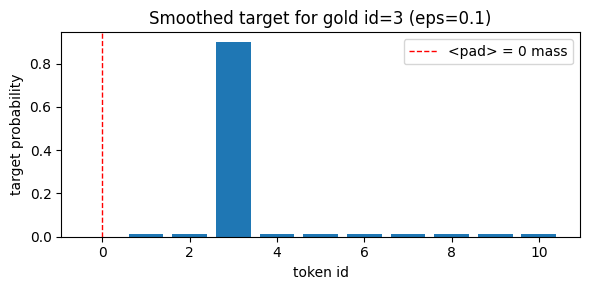

confidence on gold id 3 : 0.8999999761581421
mass on each other id   : 0.011111111380159855 (=0.1/(V-2))
mass on <pad> id 0      : 0.0


In [15]:
# ── Label smoothing as a KL-divergence loss (§5.4) ──────────────────────────                        # +-- THE TARGET IS A DISTRIBUTION, NOT A CLASS ------------------
class LabelSmoothing(nn.Module):                                                                      # | Instead of putting all the probability on the correct token,
    def __init__(self, size, padding_idx, smoothing=0.1):                                             # | nine tenths goes there and the remaining tenth is spread over
        super().__init__()                                                                            # | the other real tokens. Two classes are excluded from that
        self.criterion = nn.KLDivLoss(reduction="sum")                                                # | spread, the gold token itself and padding, which is why the
        self.padding_idx = padding_idx                                                                # | divisor is the vocabulary size minus two. The padding column
        self.confidence = 1.0 - smoothing      # mass on the true token (0.9)                         # | is then zeroed outright, so the model is never rewarded for
        self.smoothing  = smoothing            # mass to spread     (0.1)                             # | predicting a pad, and any row whose gold token is padding is
        self.size = size                       # vocab size                                           # | zeroed entirely so it contributes no loss at all. The loss is
        self.true_dist = None                                                                         # | a KL divergence with sum reduction, taking log-probabilities
                                                                                                      # | in, and it is divided by the real token count outside. The
    def forward(self, x, target):                                                                     # | effect is that the model is penalised for becoming certain,
        # x: (n_tokens, vocab) log-probabilities. target: (n_tokens,) gold ids.                       # | which keeps the logits from growing without bound and improves
        assert x.size(1) == self.size                                                                 # | BLEU in the paper while making perplexity worse. The model
        true_dist = x.data.clone()                                                                    # | still receives the true previous token in its input through
        # spread the smoothing mass over the (size-2) "other" classes                                 # | teacher forcing; only the target it is scored against softens.
        # (-2: exclude the true class and the padding class).
        true_dist.fill_(self.smoothing / (self.size - 2))
        true_dist.scatter_(1, target.unsqueeze(1), self.confidence)  # confidence on gold
        true_dist[:, self.padding_idx] = 0                           # never predict <pad>
        mask = torch.nonzero(target == self.padding_idx)             # positions that ARE pad
        if mask.dim() > 0 and mask.numel() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)            # zero their loss
        self.true_dist = true_dist
        return self.criterion(x, true_dist)

# Visualize what the smoothed target distribution looks like for one token.                           # +-- THE SMOOTHED TARGET, DRAWN ---------------------------------
crit = LabelSmoothing(size=V, padding_idx=PAD, smoothing=0.1)                                         # | The bar plot is the target vector the loss is actually
predict = torch.log(torch.ones(1, V) / V)        # dummy uniform prediction (log-probs)               # | comparing against for a single token whose correct id is
_ = crit(predict, torch.tensor([3]))             # gold token = id 3                                  # | three. One tall bar at three, eight equal short bars, and a
plt.figure(figsize=(6, 3))                                                                            # | hard zero at id zero where padding lives. The two printed
plt.bar(range(V), crit.true_dist[0].numpy())                                                          # | numbers confirm the arithmetic: nine tenths on the gold token,
plt.title("Smoothed target for gold id=3 (eps=0.1)")                                                  # | and a tenth divided among nine minus two classes on each of
plt.xlabel("token id"); plt.ylabel("target probability")                                              # | the others.
plt.axvline(0, color="r", ls="--", lw=1, label="<pad> = 0 mass"); plt.legend()
plt.tight_layout(); plt.show()
print("confidence on gold id 3 :", crit.true_dist[0,3].item())
print("mass on each other id   :", crit.true_dist[0,4].item(), "(=0.1/(V-2))")
print("mass on <pad> id 0      :", crit.true_dist[0,0].item())

## 13. The optimizer & the warmup learning-rate schedule (§5.3)

The paper uses **Adam** with `β₁=0.9, β₂=0.98, ε=10⁻⁹` — note `β₂=0.98` is lower than Adam's usual 0.999, making the second-moment estimate adapt a bit faster. The clever part is the **learning rate schedule**:

$$lrate = d_{model}^{-0.5} \cdot \min\!\left(step^{-0.5},\; step \cdot warmup^{-1.5}\right)$$

with `warmup_steps = 4000`. This produces two phases:
- **Warmup** (steps `< 4000`): the `step · warmup^{-1.5}` term dominates → learning rate **increases linearly** from ~0.
- **Decay** (steps `> 4000`): the `step^{-0.5}` term dominates → learning rate **decays** as the inverse square root of the step.

> 🔍 **Nuance — why warmup at all?** Recall the Post-LN nuance: at the start of training, gradients through a deep Post-LN stack are large and noisy. Starting Adam at a high LR would blow the model up. Warmup eases in gently, lets Adam's moment estimates stabilize, *then* ramps to the peak LR and decays. The `d_model^{-0.5}` factor scales the whole curve down for wider models. This schedule (often called "Noam") is one of the paper's quietly crucial ingredients — train without it and Post-LN Transformers often diverge.

We use a small `warmup` below to suit our tiny, fast run; we plot the curve so the two phases are unmistakable.

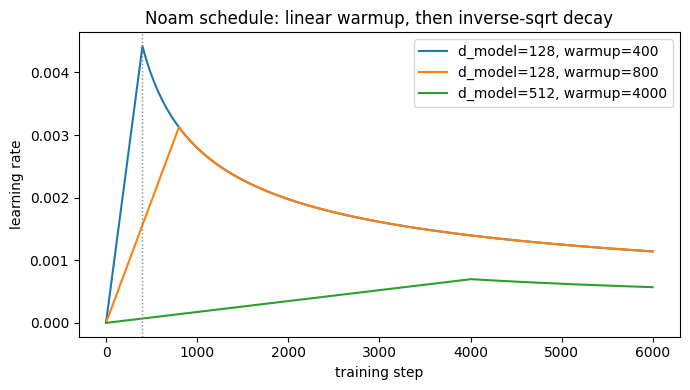

peak LR (d_model=128, warmup=400) at step 400: 4.42e-03


In [16]:
# ── Noam learning-rate schedule (§5.3) ──────────────────────────────────────                        # +-- WARM UP, THEN DECAY LIKE ONE OVER ROOT STEP ----------------
def noam_rate(step, d_model, warmup):                                                                 # | The learning rate is the minimum of two curves. Early on the
    # Guard step=0 (the formula has step^-0.5). Use max(step,1).                                      # | second term is smaller and the rate rises linearly from nearly
    step = max(step, 1)                                                                               # | zero; after the warmup step count the first term takes over
    return d_model ** (-0.5) * min(step ** (-0.5), step * warmup ** (-1.5))                           # | and the rate falls as one over the square root of the step.
                                                                                                      # | The base rate on the optimizer is set to one so the schedule
# Build the real optimizer + an LR scheduler that calls noam_rate each step.                          # | lambda is the learning rate outright rather than a multiplier
WARMUP = 400          # small warmup for our fast toy run (paper: 4000)                               # | on something else. The beta and epsilon values are the
optimizer = torch.optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)                 # | paper's.
lr_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda=lambda step: noam_rate(step, cfg.d_model, WARMUP))

# Plot the schedule for a few (d_model, warmup) settings to see both phases.                          # +-- BOTH PHASES, AND WHAT EACH KNOB MOVES ----------------------
plt.figure(figsize=(7, 4))                                                                            # | Three settings are drawn together. Raising the warmup pushes
for d_m, wu in [(128, 400), (128, 800), (512, 4000)]:                                                 # | the peak later and lowers it, because the peak height is fixed
    steps = range(1, 6000)                                                                            # | by the inverse square root of the warmup step. Raising the
    plt.plot(list(steps), [noam_rate(s, d_m, wu) for s in steps],                                     # | model width scales the whole curve down, since wider models
             label=f"d_model={d_m}, warmup={wu}")                                                     # | take smaller steps. The vertical line marks this run's warmup,
plt.axvline(400, color="gray", ls=":", lw=1)                                                          # | and the printed value is the highest learning rate this
plt.title("Noam schedule: linear warmup, then inverse-sqrt decay")                                    # | training will ever see.
plt.xlabel("training step"); plt.ylabel("learning rate"); plt.legend()
plt.tight_layout(); plt.show()
print("peak LR (d_model=128, warmup=400) at step 400:", f"{noam_rate(400,128,400):.2e}")

## 14. Training the model

We now connect every piece into a standard training loop:
1. **Forward**: `model(src, tgt, src_mask, tgt_mask)` → decoder states → `generator` → log-probs.
2. **Loss**: label-smoothed KL divergence, summed over real tokens and divided by token count.
3. **Backward**: `loss.backward()`.
4. **Step**: `optimizer.step()` then `lr_scheduler.step()` (advance the Noam LR), then zero grads.

We train on freshly-generated random batches (so there's no train/test leakage to worry about — every batch is new) and print the per-token loss. Watch it fall: a healthy Transformer on the copy task drops from ~`ln(V) ≈ 2.4` (random guessing over ~9 symbols) toward near-zero as it learns to copy.

> 🔍 **Nuance — loss normalization.** We sum the KL loss over all non-pad tokens and divide by the number of those tokens. This makes the loss comparable across batches with different amounts of padding, and matches how the paper reports per-token quantities. Mixing this up (e.g. averaging over padded positions too) silently biases the loss.

In [17]:
# ── Training loop ───────────────────────────────────────────────────────────                        # +-- ONE PASS, AND THE ORDER OF THE FOUR CALLS ------------------
import time                                                                                           # | The batch is run through the model, the decoder states are
                                                                                                      # | projected to log-probabilities, and both those and the targets
criterion = LabelSmoothing(size=V, padding_idx=PAD, smoothing=0.1).to(device)                         # | are flattened so the loss sees a flat list of token
                                                                                                      # | predictions. Dividing by the real token count makes the
def run_epoch(data_iter, model, criterion, optimizer=None, lr_scheduler=None):                        # | reported number a per-token loss, comparable across batch
    "One pass over data_iter. If optimizer is None, run in eval (no grad/step)."                      # | sizes. The four optimizer calls happen in a fixed order:
    total_loss, total_tokens = 0.0, 0                                                                 # | gradients are accumulated backwards, the step is taken, the
    for batch in data_iter:                                                                           # | schedule advances so the next step uses the next learning
        # Forward through encoder-decoder, then the generator -> log-probs.                           # | rate, and only then are gradients cleared. Clearing to none
        out = model(batch.src, batch.tgt, batch.src_mask, batch.tgt_mask)                             # | rather than to zero frees the buffers instead of writing zeros
        logp = model.generator(out)                              # (b, seq, V)                        # | over them. Stepping the schedule after the optimizer, not
        # Flatten to (b*seq, V) and (b*seq,) for the loss.                                            # | before, is what makes the first update use the first learning
        loss = criterion(logp.reshape(-1, logp.size(-1)),                                             # | rate. Passing no optimizer turns the same function into an
                         batch.tgt_y.reshape(-1)) / batch.ntokens                                     # | evaluation pass, though nothing here disables gradient
        if optimizer is not None:                                                                     # | tracking, so such a call still builds the graph and merely
            loss.backward()                                                                           # | never uses it.
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)
        total_loss += loss.item() * batch.ntokens.item()
        total_tokens += batch.ntokens.item()
    return total_loss / total_tokens

print(f"Baseline (random guessing) per-token loss ~ ln(V-2) = {math.log(V-2):.3f}\n")                 # +-- WHAT THE LOSS NUMBER HAS TO BEAT ---------------------------
torch.manual_seed(1)                                                                                  # | Guessing uniformly among the nine real symbols gives a per-
model.train()                                                                                         # | token loss of the natural log of nine, about 2.2, so any run
t0 = time.time()                                                                                      # | that does not drop well below that has learned nothing. Twenty
for epoch in range(20):                                                                               # | epochs of thirty batches is six hundred steps, which is past
    loss = run_epoch(                                                                                 # | the four-hundred-step warmup peak, so the printed learning
        data_gen(V, batch_size=64, n_batches=30, seq_len=10, device=device),                          # | rate rises for the first half of training and falls for the
        model, criterion, optimizer, lr_scheduler)                                                    # | rest.
    if epoch % 2 == 0 or epoch == 19:
        cur_lr = lr_scheduler.get_last_lr()[0]
        print(f"epoch {epoch:2d} | per-token loss {loss:.4f} | lr {cur_lr:.2e}")
print(f"\nTrained 20 epochs in {time.time()-t0:.1f}s on {device}.")

Baseline (random guessing) per-token loss ~ ln(V-2) = 2.197

epoch  0 | per-token loss 1.9239 | lr 3.31e-04
epoch  2 | per-token loss 1.3203 | lr 9.94e-04
epoch  4 | per-token loss 0.8692 | lr 1.66e-03
epoch  6 | per-token loss 0.4550 | lr 2.32e-03
epoch  8 | per-token loss 0.2211 | lr 2.98e-03
epoch 10 | per-token loss 0.1732 | lr 3.65e-03
epoch 12 | per-token loss 0.1638 | lr 4.31e-03
epoch 14 | per-token loss 0.1025 | lr 4.17e-03
epoch 16 | per-token loss 0.0977 | lr 3.91e-03
epoch 18 | per-token loss 0.1188 | lr 3.70e-03
epoch 19 | per-token loss 0.0710 | lr 3.61e-03

Trained 20 epochs in 10.9s on cuda.


## 15. Inference: autoregressive greedy decoding

Training used **teacher forcing** — we fed the model the *true* shifted target all at once. At inference time there is no ground truth: the model must generate **one token at a time**, feeding each prediction back in as the next decoder input. This is the autoregressive loop the causal mask was protecting all along.

The procedure (greedy decoding):
1. Run the encoder **once** on the source → `memory` (reused for every step).
2. Start the target with the start symbol (`1`).
3. Repeat: run the decoder on the tokens-so-far, take the generator's log-probs at the **last** position, pick the **argmax** token (greedy), append it, and continue.

> 🔍 **Nuance — greedy vs. beam search.** We use greedy (always take the top-1 token). The paper uses **beam search (beam size 4)** with a length penalty `α=0.6`, which keeps several candidate sequences alive and usually yields higher BLEU. Greedy is the simplest correct decoder and is perfect for verifying the copy task. Note also the encoder runs only once — only the decoder is re-run per step (and real systems cache past keys/values to avoid recomputation; we keep it simple here).

In [18]:
# ── Greedy decoding + test on held-out copy sequences ───────────────────────                        # +-- GENERATION: ENCODE ONCE, DECODE ONE TOKEN AT A TIME --------
def greedy_decode(model, src, src_mask, max_len, start_symbol=1):                                     # | The encoder runs a single time because its output does not
    model.eval()                                                                                      # | depend on what has been generated. The loop starts from the
    with torch.no_grad():                                                                             # | start symbol alone and appends one token per iteration. A
        memory = model.encode(src, src_mask)                 # run encoder ONCE                       # | fresh causal mask is built each step because the prefix has
        ys = torch.full((src.size(0), 1), start_symbol,      # begin with start symbol                # | grown. Only the last position's log-probabilities matter; the
                        dtype=src.dtype, device=src.device)                                           # | earlier ones would just re-predict tokens already chosen. This
        for _ in range(max_len - 1):                                                                  # | recomputes the whole prefix through the decoder every step,
            tgt_mask = subsequent_mask(ys.size(1)).to(src.device)                                     # | which is what a key-value cache would later remove. Taking the
            out = model.decode(memory, src_mask, ys, tgt_mask)                                        # | arg max is greedy decoding: no beam, so an early wrong token
            logp = model.generator(out[:, -1])               # log-probs at LAST position             # | is never revisited.
            next_token = logp.argmax(dim=-1, keepdim=True)   # greedy pick
            ys = torch.cat([ys, next_token], dim=1)          # append & loop
    return ys

# Make fresh, never-seen sequences and ask the model to copy them.                                    # +-- TESTING ON SEQUENCES THE MODEL HAS NEVER SEEN --------------
torch.manual_seed(7)                                                                                  # | The training data was generated fresh each batch, so these
test = torch.randint(2, V, size=(5, 10), device=device)                                               # | five sequences are new by construction. The comparison is
test[:, 0] = 1                                               # start symbol                           # | exact-sequence equality, not per-token accuracy, so one wrong
test_mask = make_pad_mask(test)                                                                       # | symbol fails the whole line. The check is strict on purpose:
pred = greedy_decode(model, test, test_mask, max_len=10, start_symbol=1)                              # | copying is easy enough that a working implementation should
                                                                                                      # | reach five out of five, and anything less points at a bug in
correct = 0                                                                                           # | the masking or the shift rather than at undertraining. The
for i in range(test.size(0)):                                                                         # | source is passed with its own padding mask even though nothing
    src_seq  = test[i].tolist()                                                                       # | is padded here, because the decoder's cross-attention takes
    pred_seq = pred[i].tolist()                                                                       # | that mask on every step and the shape must be right.
    ok = src_seq == pred_seq
    correct += ok
    print(f"src : {src_seq}")
    print(f"pred: {pred_seq}   {'✅ exact copy' if ok else '❌'}\n")
print(f"Exact-copy accuracy on unseen sequences: {correct}/{test.size(0)}")

src : [1, 2, 6, 5, 2, 4, 4, 6, 4, 6]
pred: [1, 2, 6, 5, 2, 4, 4, 6, 4, 6]   ✅ exact copy

src : [1, 4, 4, 10, 2, 9, 2, 9, 6, 8]
pred: [1, 4, 4, 10, 2, 9, 2, 9, 6, 8]   ✅ exact copy

src : [1, 6, 6, 8, 4, 4, 7, 4, 7, 3]
pred: [1, 6, 6, 8, 4, 4, 7, 4, 7, 3]   ✅ exact copy

src : [1, 7, 2, 2, 4, 5, 10, 5, 7, 10]
pred: [1, 7, 2, 2, 4, 5, 10, 5, 7, 10]   ✅ exact copy

src : [1, 4, 8, 10, 7, 5, 8, 5, 7, 8]
pred: [1, 4, 8, 10, 7, 5, 8, 5, 7, 8]   ✅ exact copy

Exact-copy accuracy on unseen sequences: 5/5


## 16. Looking inside: visualizing attention

The paper's Figures 3–5 visualize attention weights to show heads learning interpretable roles. We can do the same with *our* trained model, because every `MultiHeadAttention` module stashed its last weight matrix in `self.attn` (shape `batch × heads × query × key`).

For the copy task, the most revealing place is the **decoder→encoder cross-attention**: to emit the symbol at output position `i`, the model must look at **source position `i`**. If it learned to copy, the cross-attention should be a near-perfect **diagonal** — each output token attending to the matching input token.

We'll run one sequence through the model and plot the cross-attention of each head in the last decoder layer. Watch for the diagonal stripe — that's the model literally pointing at the symbol it's about to copy.

> 🔍 **Nuance — heads specialize.** Don't expect *every* head to show the clean diagonal. As the paper notes, *"the heads clearly learned to perform different tasks"* — some will be diagonal copiers, others may attend to the start symbol, neighbors, or look almost uniform (effectively unused). That division of labor is exactly what multi-head attention buys you.

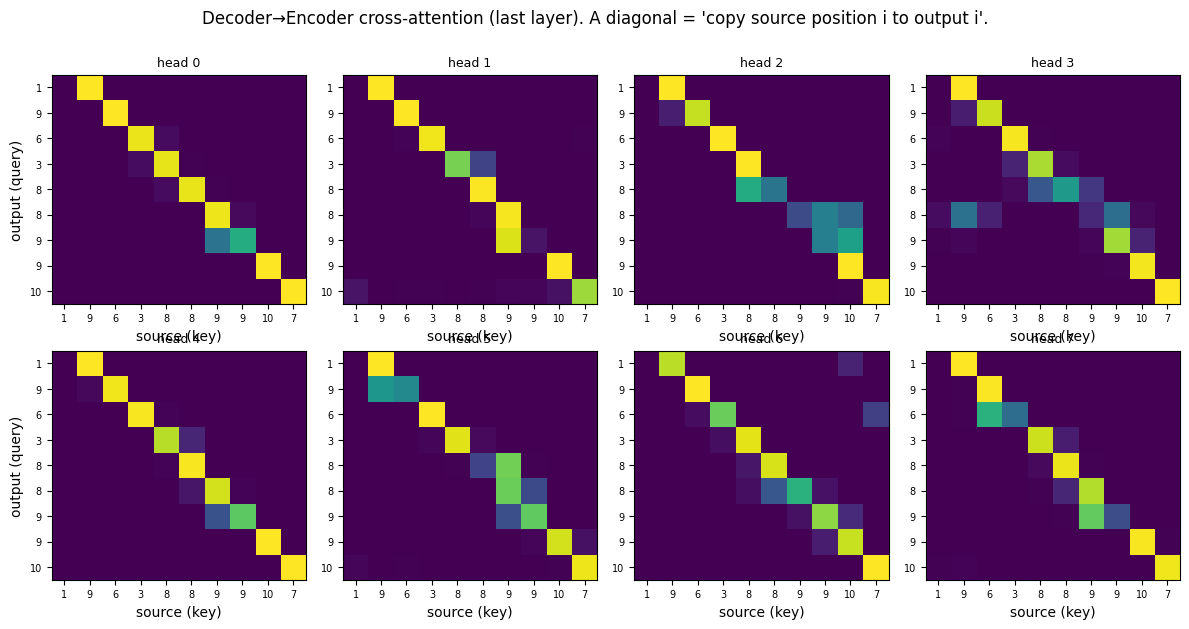

Per-head average mass on the 'copy' diagonal (higher = sharper copier):
  head 0: 0.94
  head 1: 0.85
  head 2: 0.77
  head 3: 0.81
  head 4: 0.95
  head 5: 0.79
  head 6: 0.88
  head 7: 0.81


In [19]:
# ── Visualize the decoder->encoder cross-attention of every head ────────────                        # +-- READING THE WEIGHTS BACK OUT OF A TRAINED MODEL ------------
# Run one sequence through teacher-forced forward so every layer fills self.attn.                     # | A teacher-forced forward pass is run purely for its side
torch.manual_seed(3)                                                                                  # | effect: every attention module stores its last weight tensor,
seq = torch.randint(2, V, size=(1, 10), device=device); seq[:, 0] = 1                                 # | so one pass fills them all in. Evaluation mode matters here
b = Batch(seq, seq, pad=PAD)                                                                          # | because dropout would otherwise randomly zero entries of the
model.eval()                                                                                          # | very weights being plotted. The tensor taken is the cross-
with torch.no_grad():                                                                                 # | attention of the final decoder layer, indexed by head, then
    _ = model(b.src, b.tgt, b.src_mask, b.tgt_mask)                                                   # | output position, then source position, which is the map from
                                                                                                      # | what is being generated to what is being read.
# The cross-attention lives in src_attn of the LAST decoder layer.
cross = model.decoder.layers[-1].src_attn.attn[0]   # (heads, query=tgt, key=src)
H = cross.size(0)
src_tokens = seq[0].tolist()
tgt_tokens = b.tgt[0].tolist()

fig, axes = plt.subplots(2, H // 2, figsize=(3 * (H // 2), 6))                                        # +-- WHAT A SOLVED COPY TASK LOOKS LIKE -------------------------
for h, ax in enumerate(axes.flat):                                                                    # | Each head is drawn on a fixed zero-to-one colour scale so
    ax.imshow(cross[h].cpu().numpy(), cmap="viridis", vmin=0, vmax=1)                                 # | heads are comparable to each other rather than each being
    ax.set_title(f"head {h}", fontsize=9)                                                             # | auto-scaled to its own range. Rows are output positions and
    ax.set_xticks(range(len(src_tokens)));  ax.set_xticklabels(src_tokens, fontsize=7)                # | columns are source positions, both labelled with the actual
    ax.set_yticks(range(len(tgt_tokens)));  ax.set_yticklabels(tgt_tokens, fontsize=7)                # | token ids. A head that has learned to copy shows a bright line
    if h % (H // 2) == 0: ax.set_ylabel("output (query)")                                             # | one step off the main diagonal; a head that has learned
    ax.set_xlabel("source (key)")                                                                     # | something else, or nothing, shows a blur or a vertical stripe.
fig.suptitle("Decoder→Encoder cross-attention (last layer). "
             "A diagonal = 'copy source position i to output i'.", y=1.02)
plt.tight_layout(); plt.show()

# Quantify how 'diagonal' each head is: average attention mass on the matching                        # +-- THE DIAGONAL, MEASURED INSTEAD OF EYEBALLED ----------------
# source position. (Output position i should attend to source position i+1, because                   # | The mass sitting on the copy diagonal is averaged per head.
# of the right-shift: tgt input[i] predicts source[i+1].)                                             # | The offset of one is the right-shift: decoder input position i
print("Per-head average mass on the 'copy' diagonal (higher = sharper copier):")                      # | is the token before the one it must predict, so the source
for h in range(H):                                                                                    # | position it needs is i plus one. Heads split into sharp
    diag = cross[h].diagonal(offset=1).mean().item()   # offset=1 accounts for the shift              # | copiers and near-zero ones, which is the redundancy multi-head
    print(f"  head {h}: {diag:.2f}")                                                                  # | attention buys on a task that only needs one route.

## 17. Recap — what we built, the nuances, and how 2017 differs from today

### You implemented the entire paper, from scratch
| Component | Paper | Verified here |
|---|---|---|
| Sinusoidal positional encoding | §3.5 | ✓ + proved the linear-offset property to 1e-5 |
| Scaled dot-product attention | §3.2.1, Eq.(1) | ✓ + demonstrated `Var(q·k)=dₖ` (footnote 4) |
| Multi-head attention (h=8) | §3.2.2 | ✓ fused-projection implementation |
| Position-wise FFN (4× width) | §3.3 | ✓ |
| Residual + LayerNorm (Post-LN) | §3.1 | ✓ |
| Padding + causal masks | §3.2.3 | ✓ visualized |
| Embedding ×√d_model, generator | §3.4 | ✓ measured the scaling effect |
| Encoder/Decoder stacks | §3.1 | ✓ |
| Adam + Noam warmup schedule | §5.3 | ✓ plotted |
| Dropout + label smoothing | §5.4 | ✓ |
| Greedy autoregressive decoding | §6.1 | ✓ 5/5 exact copies |
| Attention visualization | Figs 3–5 | ✓ diagonal copy heads |

### The nuances worth carrying with you
1. **`/√dₖ` is about gradients, not just normalization.** Unscaled logits grow like `√dₖ`, saturate softmax, and kill its gradient. We saw the variance blow up and the entropy collapse.
2. **Position is *added*, not concatenated** — and embeddings are scaled by `√d_model` so token identity isn't drowned out by position.
3. **Two masks, two jobs.** Causal mask (decoder self-attn) preserves autoregression; padding mask (everywhere) ignores `<pad>`. The decoder self-attn mask is their AND.
4. **Right-shift + causal mask** = train on a whole sequence in parallel while staying autoregressive. This is the trick that makes Transformers fast to train.
5. **Warmup exists because of Post-LN.** Early gradients are unstable; warmup eases Adam in. Pre-LN (modern) often removes the need.
6. **Multi-head = division of labor.** Heads specialize (we saw diagonal copiers + fuzzier heads). One head's averaging would inhibit this.
7. **Label smoothing trades perplexity for BLEU/accuracy** — deliberately making the model less certain regularizes it.

### What changed between this paper (2017) and modern Transformers
- **Pre-LN** (norm *inside* the residual) is now standard — more stable, often no warmup.
- **Activations**: ReLU → GeLU/SwiGLU in the FFN.
- **Positional info**: fixed sinusoids → **RoPE** (rotary) or ALiBi, which encode *relative* position directly in attention and extrapolate better.
- **Normalization**: LayerNorm → **RMSNorm** (cheaper).
- **Decoder-only** models (GPT family) dropped the encoder entirely for generative LM; this paper's encoder-decoder still rules translation and T5-style tasks.
- **Efficiency**: FlashAttention, KV-caching, grouped-query attention, and `O(n²)` mitigations for long context.

### Try it yourself (great next experiments)
- Set `n_layers=6, d_model=512` (the real "base") and watch params/compute grow.
- **Remove** positional encoding (`x = x` in `PositionalEncoding.forward`) — the copy task should degrade, proving order matters.
- **Remove** the `/√dₖ` scaling for `d_k=64` and watch training destabilize.
- Swap the copy task for a **reverse** task (`tgt = src.flip(-1)`) — cross-attention should learn an **anti-diagonal**.
- Implement **weight tying** (share `src_embed[0].lut.weight`, `tgt_embed[0].lut.weight`, and `generator.proj.weight`) and compare parameter counts.

You now have a working, inspectable Transformer and a mental model for every line of it. 🎉